In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [5]:
data = pd.read_csv(r"C:\Users\amrel\Downloads\Education.csv")
data.head()

,Names,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate
0,Abilene Christian University,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Names        777 non-null    object 
 1   Apps         777 non-null    int64  
 2   Accept       777 non-null    int64  
 3   Enroll       777 non-null    int64  
 4   Top10perc    777 non-null    int64  
 5   Top25perc    777 non-null    int64  
 6   F_Undergrad  777 non-null    int64  
 7   P_Undergrad  777 non-null    int64  
 8   Outstate     777 non-null    int64  
 9   Room_Board   777 non-null    int64  
 10  Books        777 non-null    int64  
 11  Personal     777 non-null    int64  
 12  PhD          777 non-null    int64  
 13  Terminal     777 non-null    int64  
 14  S_F_Ratio    777 non-null    float64
 15  perc_alumni  777 non-null    int64  
 16  Expend       777 non-null    int64  
 17  Grad_Rate    777 non-null    int64  
dtypes: float64(1), int64(16), object(1)
memory usage: 

In [7]:
data.Names.nunique()

777

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Apps,777.0,3001.638353,3870.201484,81.0,776.0,1558.0,3624.0,48094.0
Accept,777.0,2018.804376,2451.113971,72.0,604.0,1110.0,2424.0,26330.0
Enroll,777.0,779.972973,929.176190,35.0,242.0,434.0,902.0,6392.0
Top10perc,777.0,27.558559,17.640364,1.0,15.0,23.0,35.0,96.0
Top25perc,777.0,55.796654,19.804778,9.0,41.0,54.0,69.0,100.0
F_Undergrad,777.0,3699.907336,4850.420531,139.0,992.0,1707.0,4005.0,31643.0
P_Undergrad,777.0,855.298584,1522.431887,1.0,95.0,353.0,967.0,21836.0
Outstate,777.0,10440.669241,4023.016484,2340.0,7320.0,9990.0,12925.0,21700.0
Room_Board,777.0,4357.526384,1096.696416,1780.0,3597.0,4200.0,5050.0,8124.0
Books,777.0,549.380952,165.105360,96.0,470.0,500.0,600.0,2340.0


In [11]:
data[(data.PhD > 100) | (data.Grad_Rate > 100)]

,Names,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate
95,Cazenovia College,3847,3433,527,9,35,1010,12,9384,4840,600,500,22,47,14.3,20,7697,118
582,Texas A&M University at Galveston,529,481,243,22,47,1206,134,4860,3122,600,650,103,88,17.4,16,6415,43


In [12]:
data.loc[582, "PhD"] = 100
data.loc[95, "Grad_Rate"] = 100

Apps
Skew : 3.72


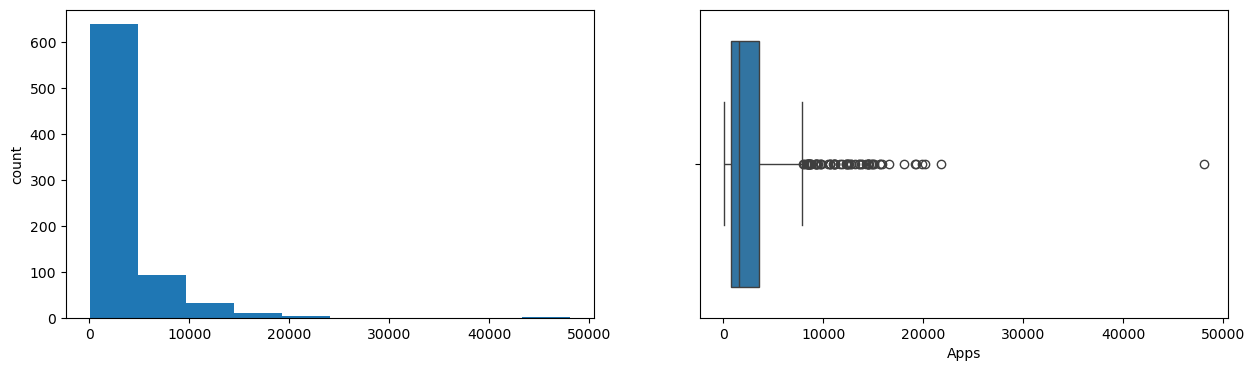

Accept
Skew : 3.42


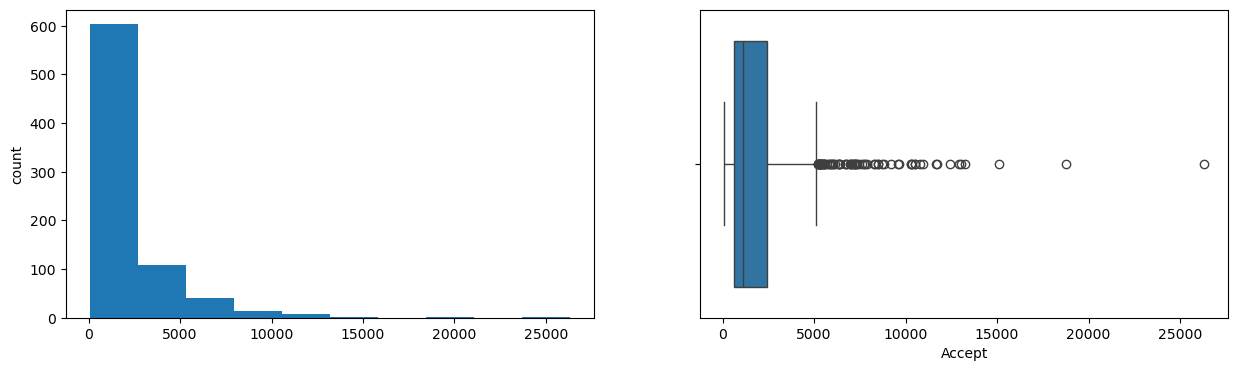

Enroll
Skew : 2.69


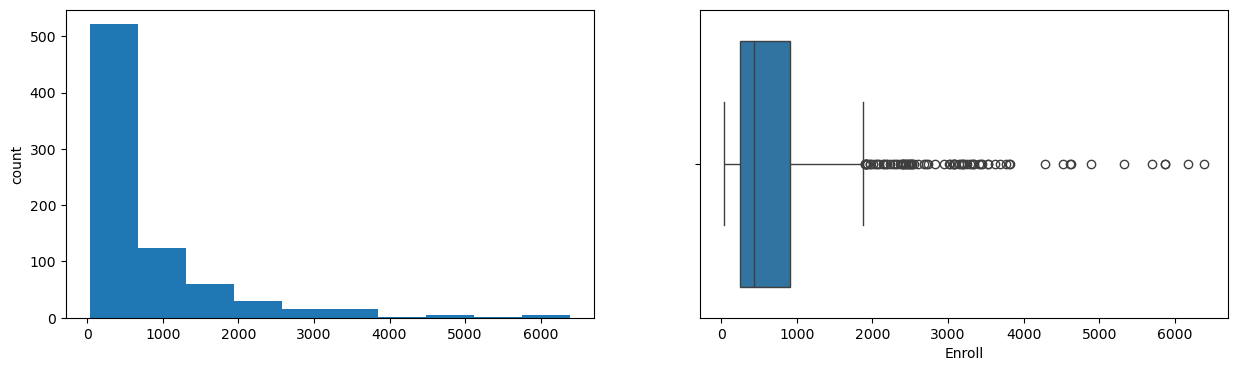

Top10perc
Skew : 1.41


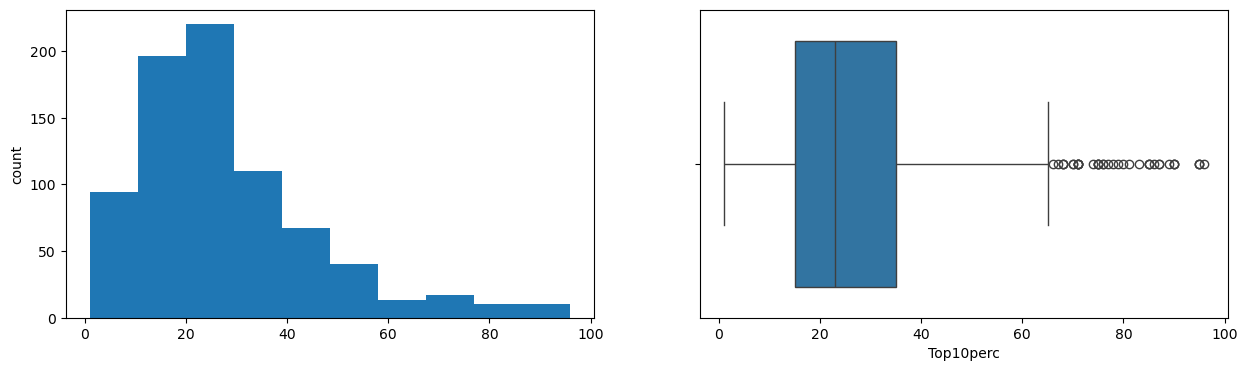

Top25perc
Skew : 0.26


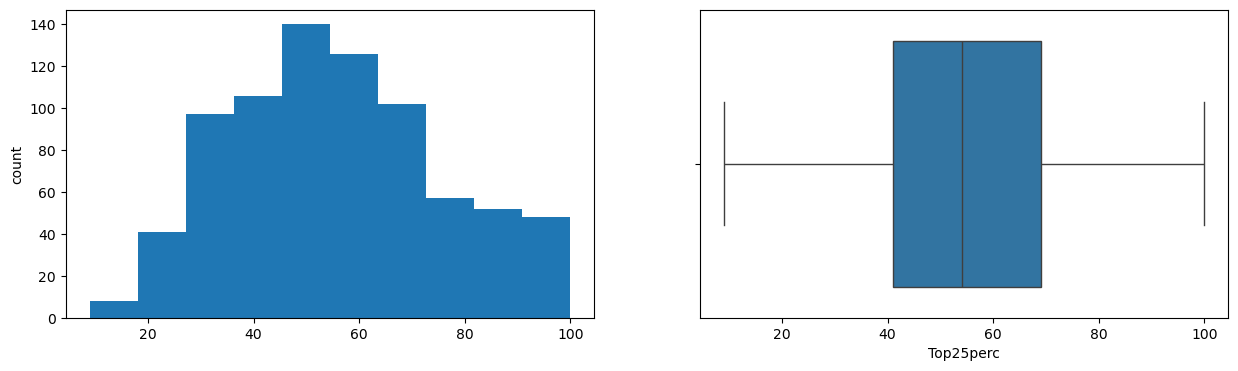

F_Undergrad
Skew : 2.61


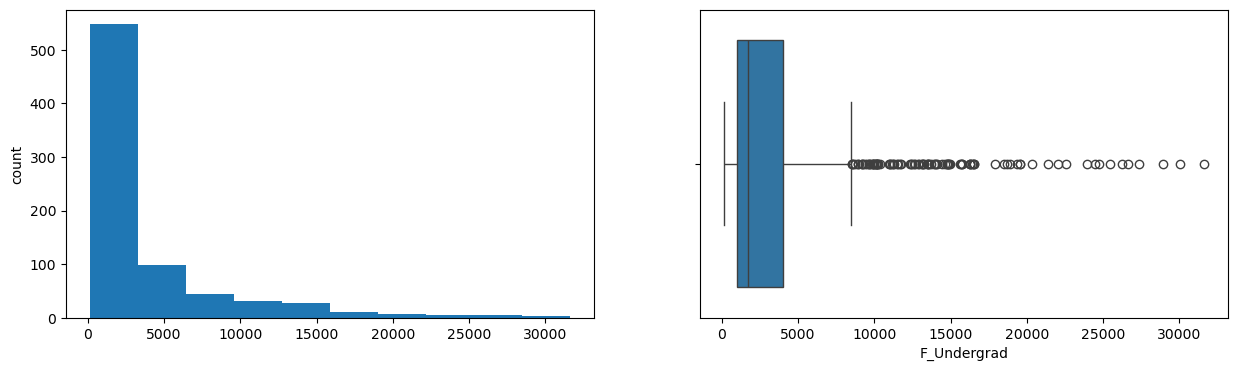

P_Undergrad
Skew : 5.69


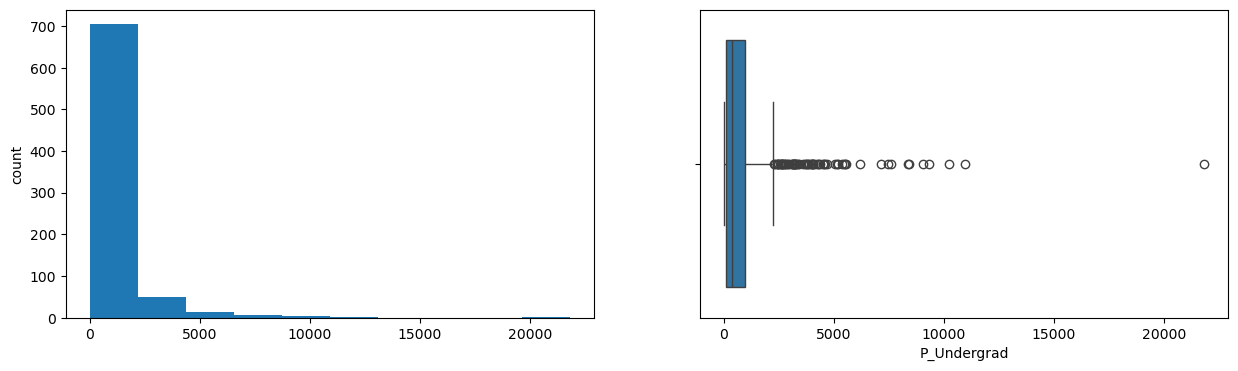

Outstate
Skew : 0.51


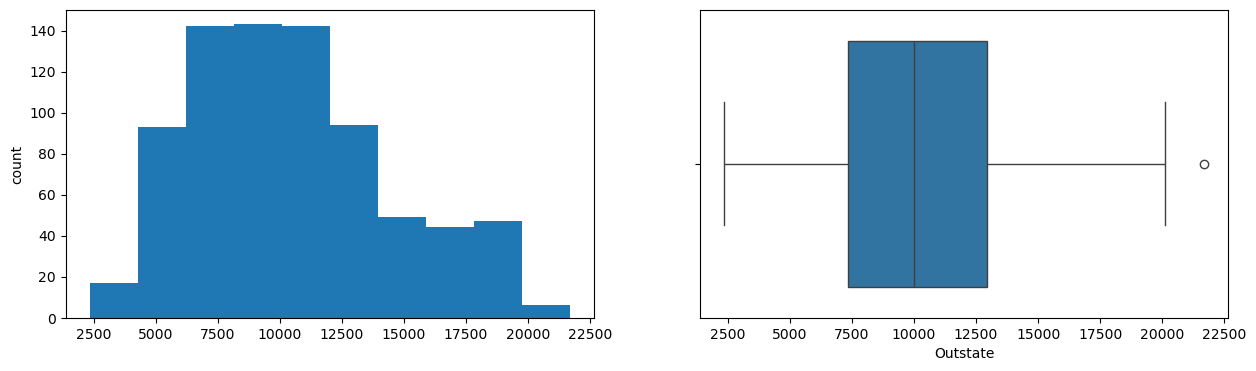

Room_Board
Skew : 0.48


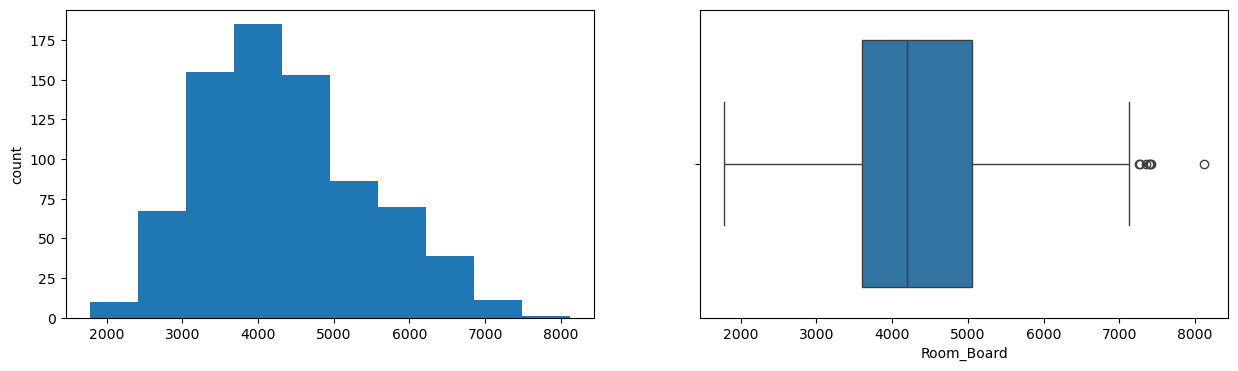

Books
Skew : 3.49


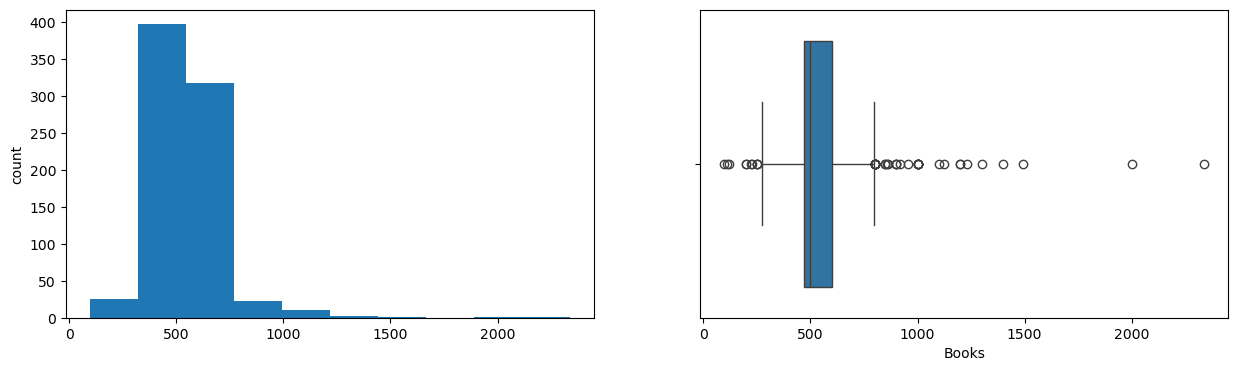

Personal
Skew : 1.74


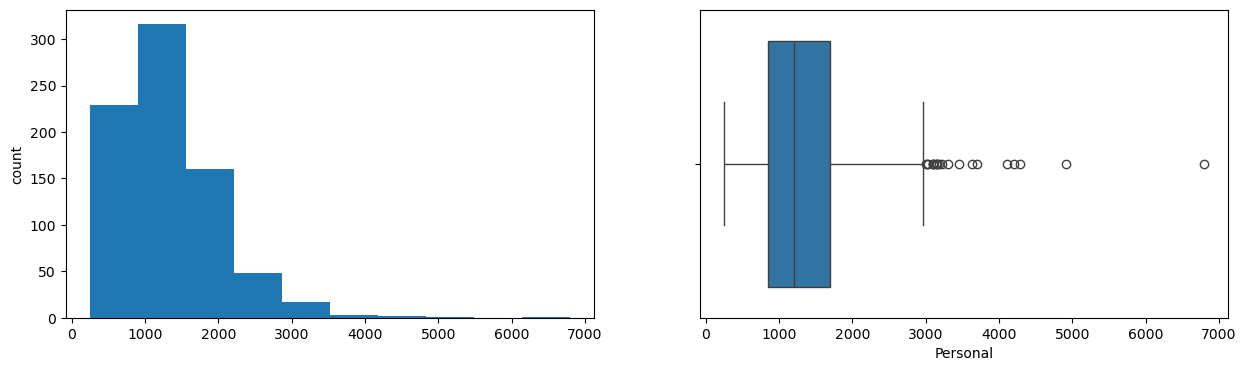

PhD
Skew : -0.77


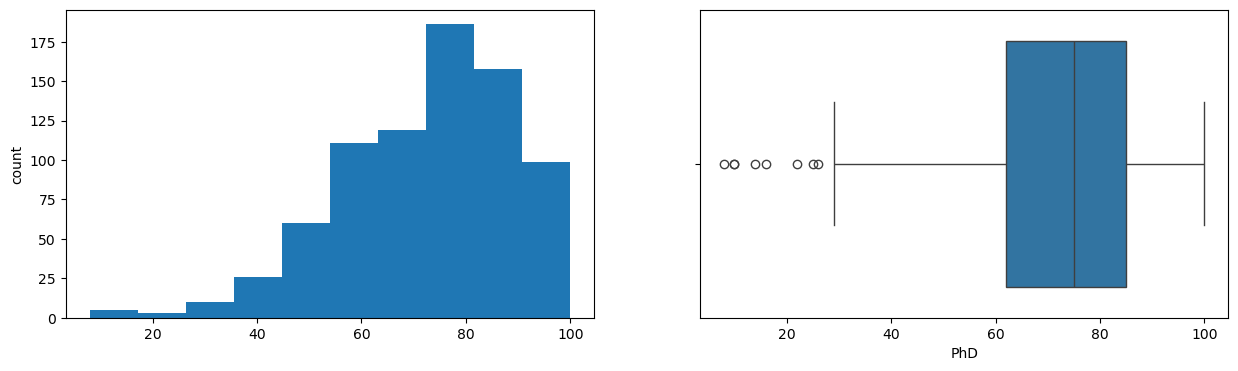

Terminal
Skew : -0.82


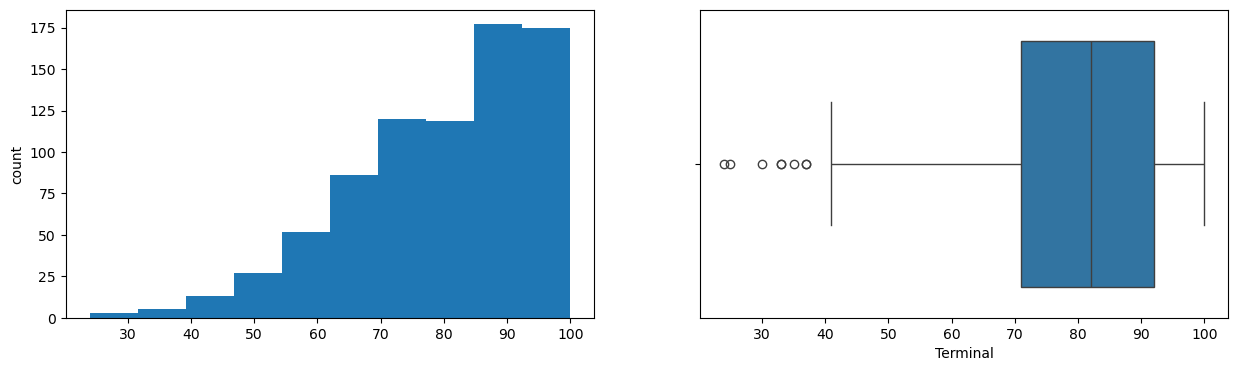

S_F_Ratio
Skew : 0.67


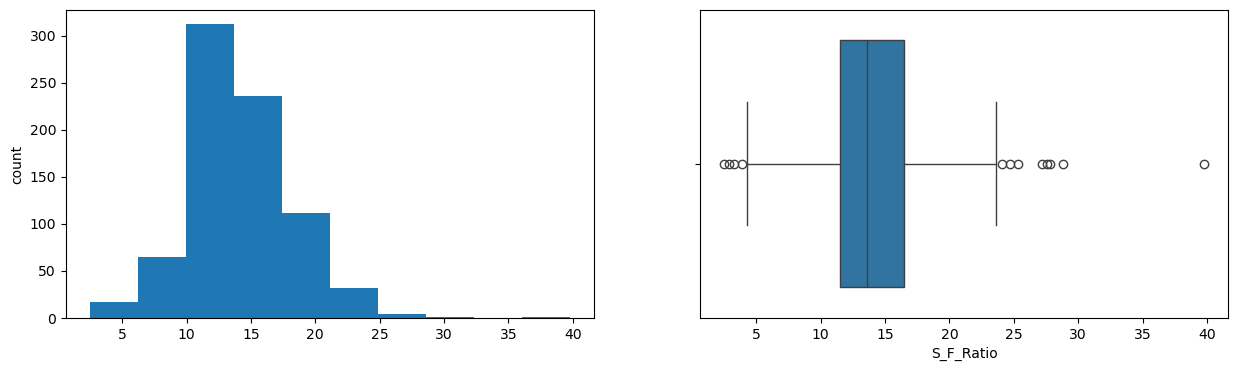

perc_alumni
Skew : 0.61


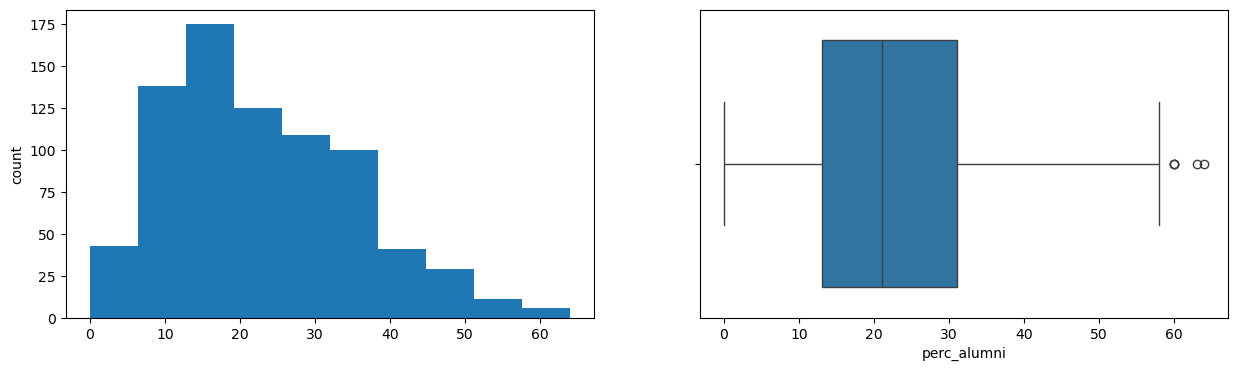

Expend
Skew : 3.46


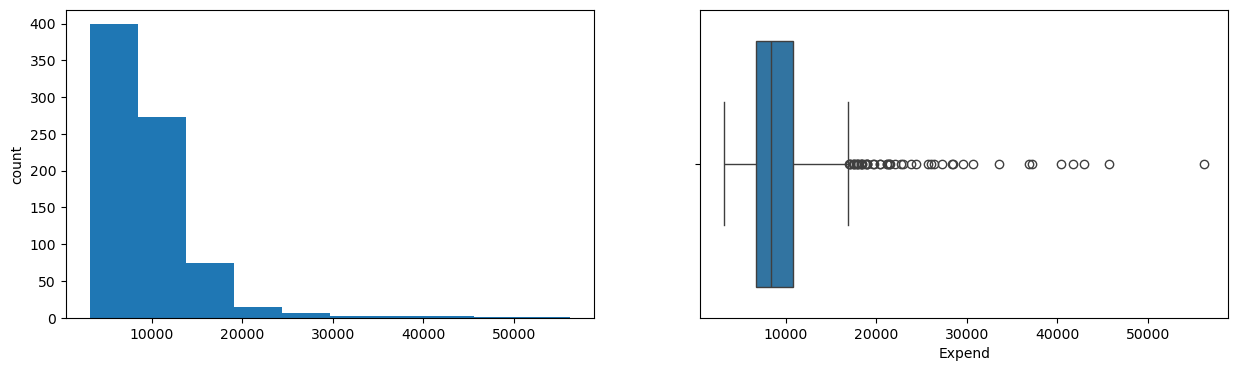

Grad_Rate
Skew : -0.14


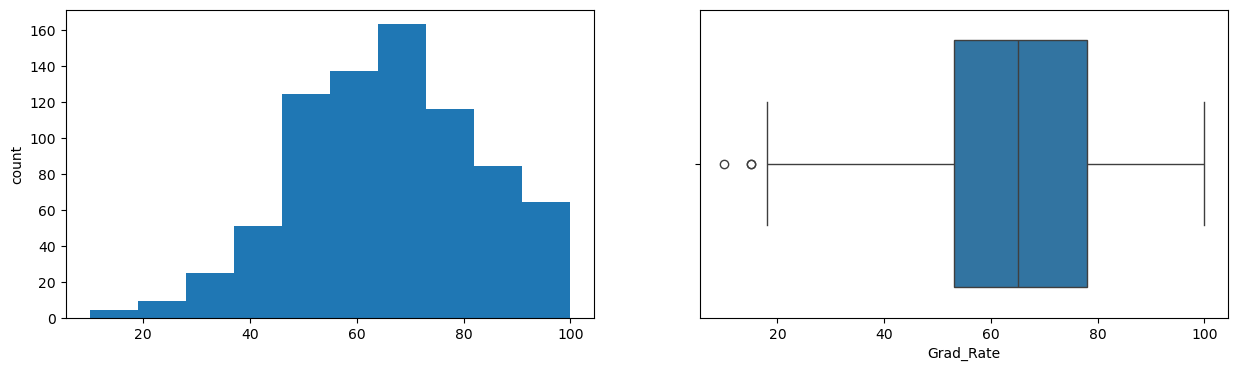

In [17]:
cont_cols = list(data.select_dtypes(include='number').columns)

for col in cont_cols:
    print(col)
    print('Skew :', round(data[col].skew(), 2))

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 2, 1)
    data[col].hist(bins=10, grid=False)
    plt.ylabel('count')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[col])

    plt.show()

The distribution plots show that Apps, Enroll, Top10Perc, F_Undergrad, P_Undergrad, Books, Personal, and Expand variables are highly right skewed. It is evident from the boxplots that all these variables have outliers

Top25percent is the only variable which does not possess outliers in the box plot

outstate, Room_Boardm S_F_Ratio, and perc_alumni seem to have a moderate right skew 

PhD and Terminal are moderately left skewed

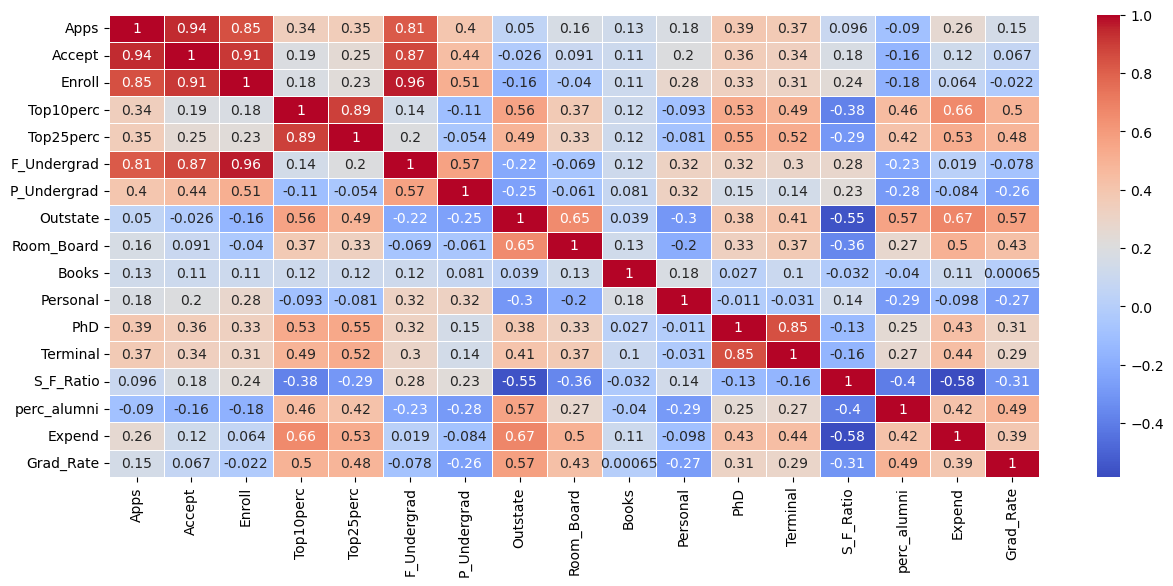

In [24]:
plt.figure(figsize=(15, 6))
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

Observations:

We can see a high positive correlation among the following variables:
Apps and Accept, 
Apps and Enroll, 
Apps and F_Undergrad, 
Accept and Enroll, 
Accept and F_Undergrad, 
Enroll and F_Undergrad, 
Top10perc and Top25percent, 
PhD and Terminal-------
We can see a high negative correlation among the following variables:
S_F_Ratio and Top10perc, 
S_F_Ratio and Outstate

Scaling the data

In [29]:
data_ = data.select_dtypes(include='number')

scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data_.values), columns=data_.columns)
data_scaled.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate
0,-0.346882,-0.321205,-0.063509,-0.258583,-0.191827,-0.168116,-0.209207,-0.746356,-0.964905,-0.602312,1.270045,-0.162859,-0.115729,1.013776,-0.867574,-0.501910,-0.317993
1,-0.210884,-0.038703,-0.288584,-0.655656,-1.353911,-0.209788,0.244307,0.457496,1.909208,1.215880,0.235515,-2.676529,-3.378176,-0.477704,-0.544572,0.166110,-0.551805
2,-0.406866,-0.376318,-0.478121,-0.315307,-0.292878,-0.549565,-0.497090,0.201305,-0.554317,-0.905344,-0.259582,-1.205112,-0.931341,-0.300749,0.585935,-0.177290,-0.668710
3,-0.668261,-0.681682,-0.692427,1.840231,1.677612,-0.658079,-0.520752,0.626633,0.996791,-0.602312,-0.688173,1.185939,1.175657,-1.615274,1.151188,1.792851,-0.376446
4,-0.726176,-0.764555,-0.780735,-0.655656,-0.596031,-0.711924,0.009005,-0.716508,-0.216723,1.518912,0.235515,0.204995,-0.523535,-0.553542,-1.675079,0.241803,-2.948375


In [31]:
n = data_scaled.shape[1]

pca = PCA(n_components=n, random_state=1)

data_pca1 = pd.DataFrame(pca.fit_transform(data_scaled))
exp_var = pca.explained_variance_ratio_

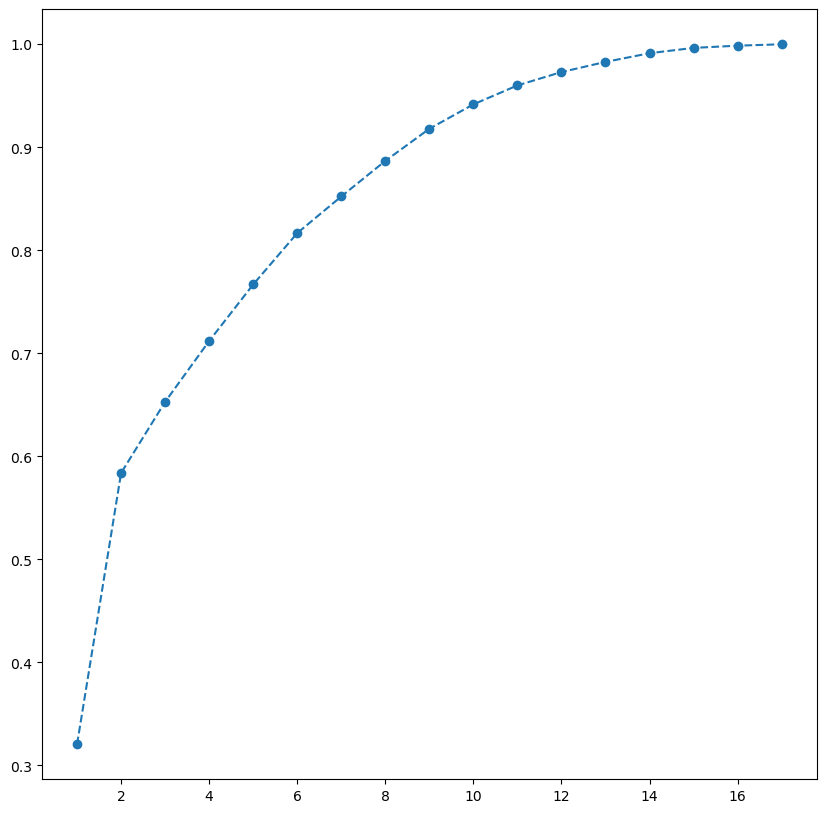

In [32]:
plt.figure(figsize=(10, 10))

plt.plot(range(1, 18), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')

plt.show()

In [33]:
sum = 0

for ix, i in enumerate(exp_var):
    sum = sum + i

    if(sum> 0.70):
        print("Number of PCs that exmplain at least 70% variance:", ix + 1)
        break

Number of PCs that exmplain at least 70% variance: 4


out of the 17 features, we have reduced the number of features through PCA to 4 principal componenets, The first four principal components explain approximately 70% of the original variance, so that is about 76% reduction in the dimensionality with only loss of 30% in variance

In [41]:
pc_comps = ['PC1', 'PC2', 'PC3', 'PC4']

data_pca = pd.DataFrame(np.round(pca.components_[:4,:],2), index = pc_comps, columns = data_scaled.columns)

data_pca.T

,PC1,PC2,PC3,PC4
Apps,0.25,0.33,-0.06,-0.28
Accept,0.21,0.37,-0.10,-0.27
Enroll,0.18,0.40,-0.08,-0.16
Top10perc,0.35,-0.08,0.03,0.05
Top25perc,0.34,-0.04,-0.02,0.11
F_Undergrad,0.15,0.42,-0.06,-0.10
P_Undergrad,0.03,0.32,0.14,0.16
Outstate,0.29,-0.25,0.05,-0.13
Room_Board,0.25,-0.14,0.15,-0.19
Books,0.06,0.06,0.68,-0.08


In [40]:
def color_high(val):

    if val < -0.25:
        return 'background-color: blue'
    elif val > 0.25:
        return 'background-color: green'
data_pca.T.style.applymap(color_high)

C:\Users\amrel\AppData\Local\Temp\ipykernel_30600\3026984252.py:7: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  data_pca.T.style.applymap(color_high)


,PC1,PC2,PC3,PC4
Apps,0.250000,0.330000,-0.060000,-0.280000
Accept,0.210000,0.370000,-0.100000,-0.270000
Enroll,0.180000,0.400000,-0.080000,-0.160000
Top10perc,0.350000,-0.080000,0.030000,0.050000
Top25perc,0.340000,-0.040000,-0.020000,0.110000
F_Undergrad,0.150000,0.420000,-0.060000,-0.100000
P_Undergrad,0.030000,0.320000,0.140000,0.160000
Outstate,0.290000,-0.250000,0.050000,-0.130000
Room_Board,0.250000,-0.140000,0.150000,-0.190000
Books,0.060000,0.060000,0.680000,-0.080000


looking at the data, PC1 seems to be related to high values scores, number of outstate students, the faculty level, and the instructional expenditure. the first component seems to capture attributes that generaly define premier colleges with quality of students.

the second component PC2 seems to be related to high values of number of applications received, accepted, enroll, F undergrad, P Undergrad. 

the third component seems to capture books, personal, and it also associated with low scores of student faculty ratio

the fourth componnet seems to be related to lower values to faculty education level and high values of students graduation rate. The fourth component to capture attributes that define colleges which lack highly educated faculty and comparatively easier to graduate from 

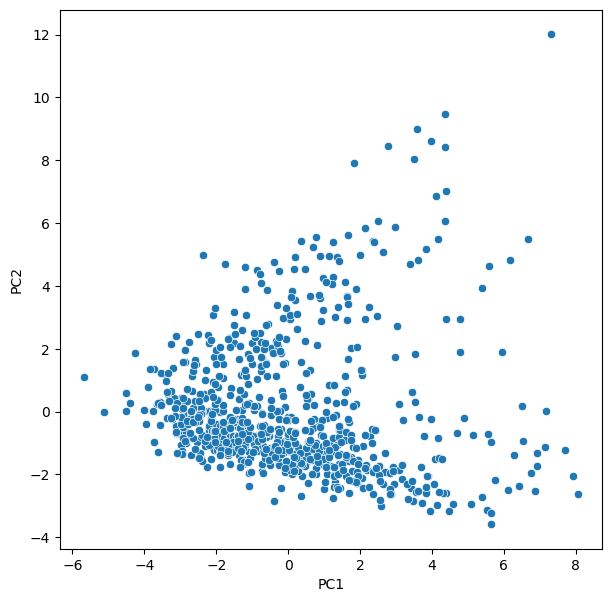

In [42]:
plt.figure(figsize=(7,7))

sns.scatterplot(x = data_pca1[0], y = data_pca1[1])

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

Now lets explore T-SNE

In [43]:
tsne = TSNE(n_components = 2, random_state = 1)
data_tsne = tsne.fit_transform(data_scaled)

In [44]:
data_tsne = pd.DataFrame(data_tsne, columns = ['X1', 'X2'])

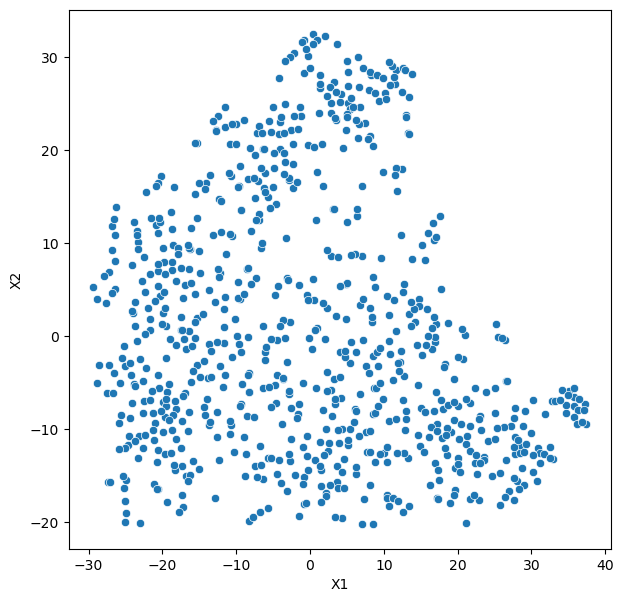

In [45]:
plt.figure(figsize=(7,7))
sns.scatterplot(x = data_tsne.X1, y = data_tsne.X2, data = data_tsne)
plt.show()

In [46]:
tsne = TSNE(n_components = 3, random_state = 1)
data_tsne = tsne.fit_transform(data_scaled)

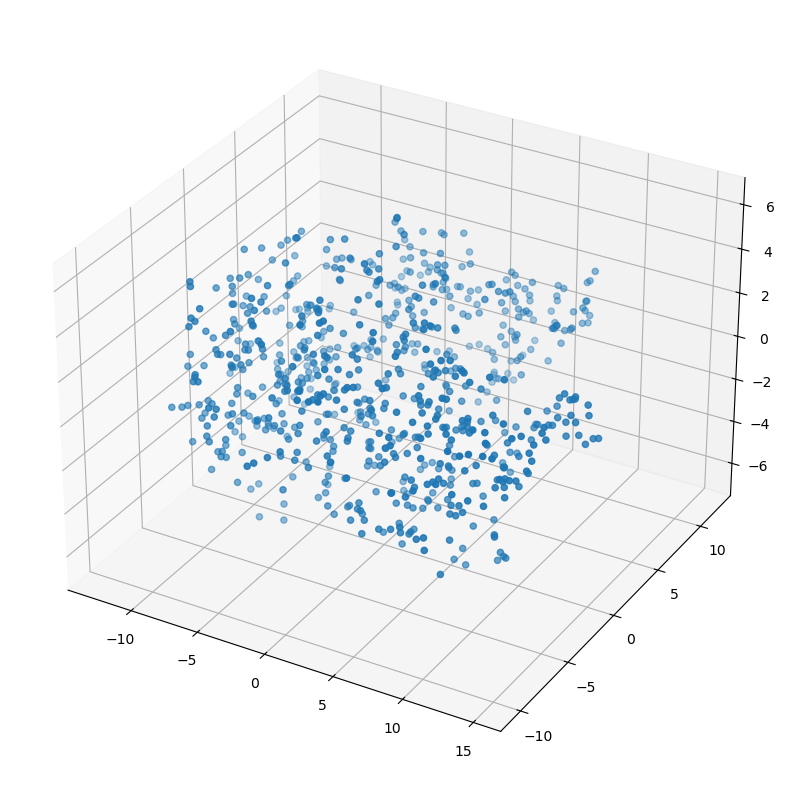

In [49]:
data_tsne = pd.DataFrame(data_tsne, columns = ['X1', 'X2', 'X3'])
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
x = data_tsne['X1']
y = data_tsne['X2']
z = data_tsne['X3']

ax.scatter(x, y, z)
plt.show()


After generateing the data in 2d and 3d, we can see that there is no pattern in the data -  it is scattered and clustered together with the exception of some outliers 

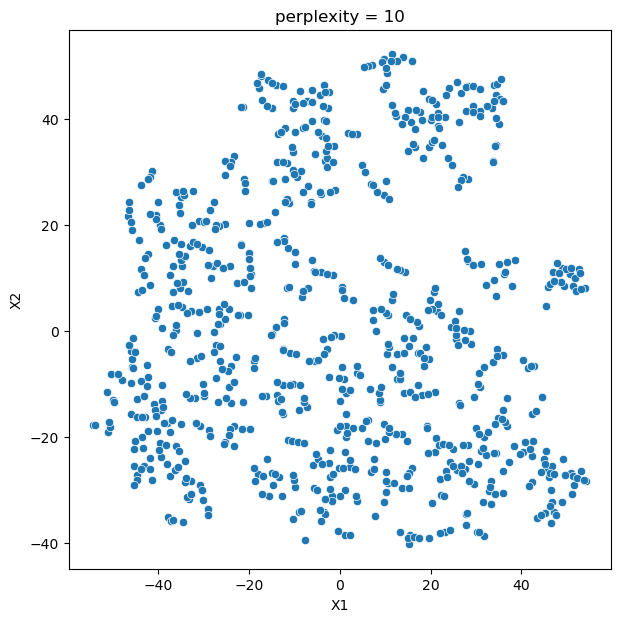

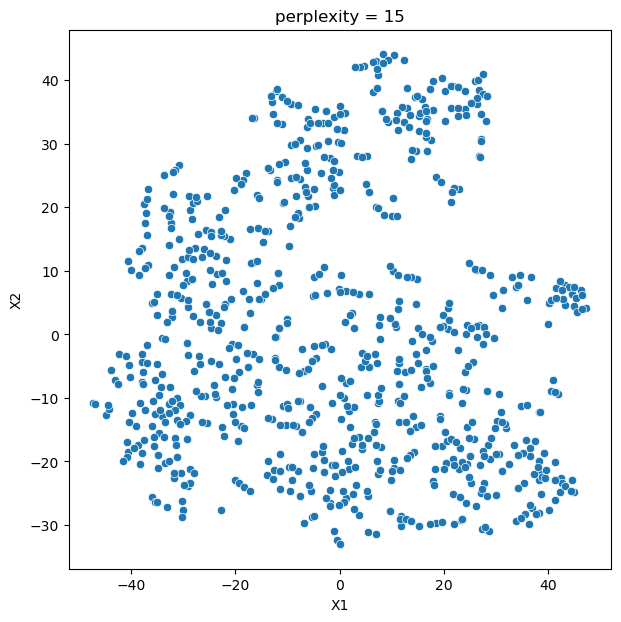

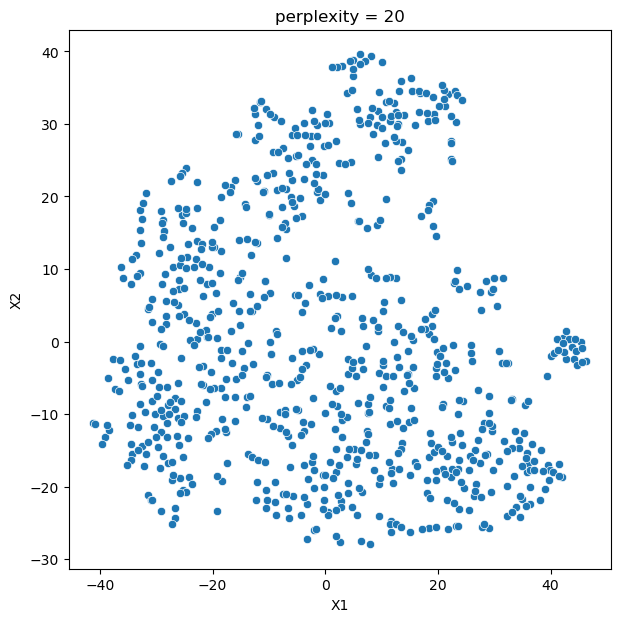

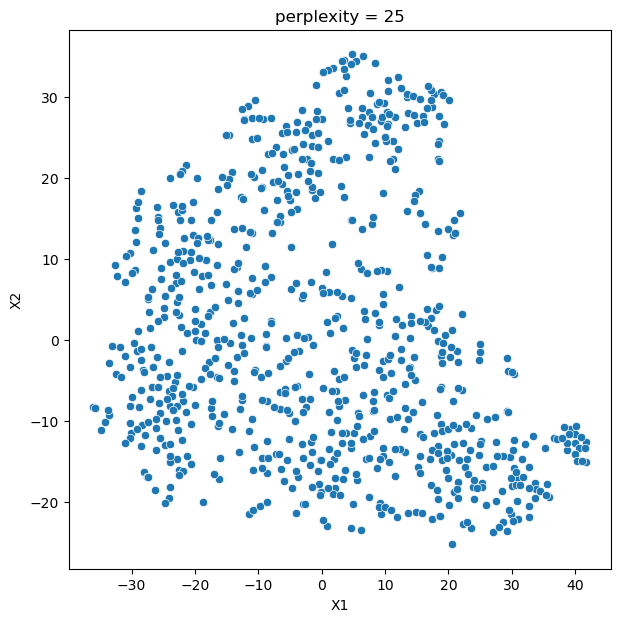

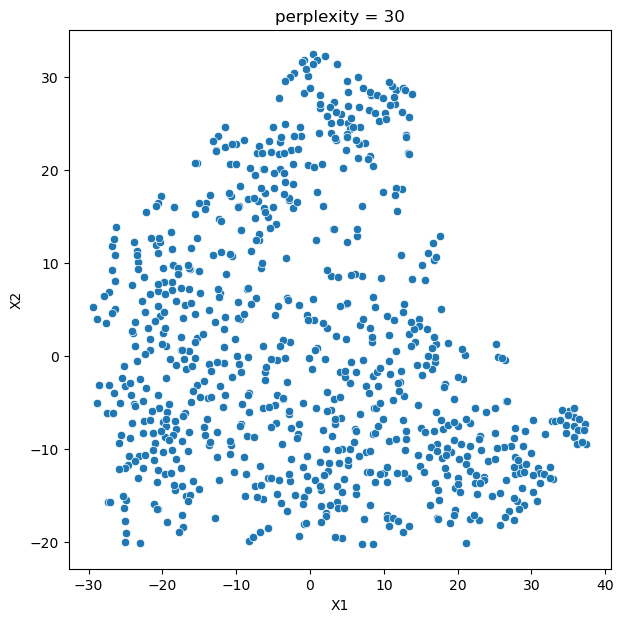

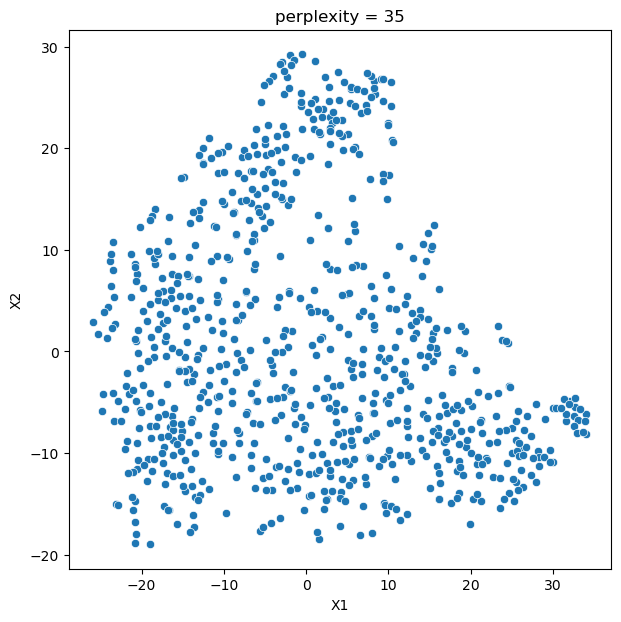

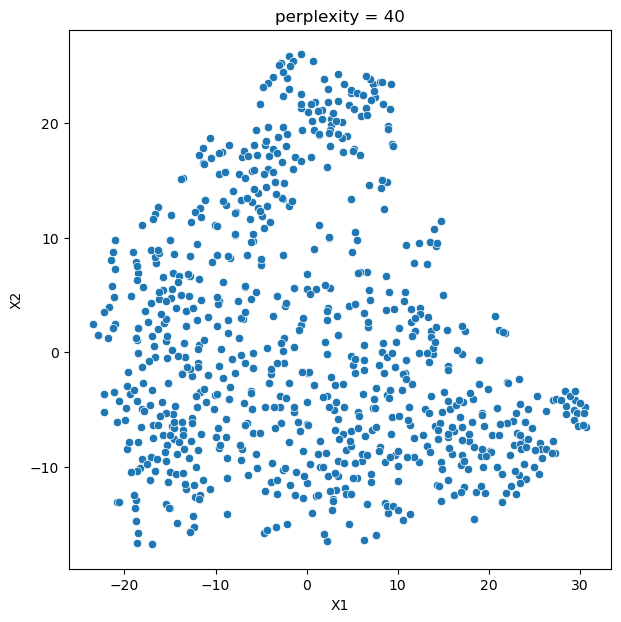

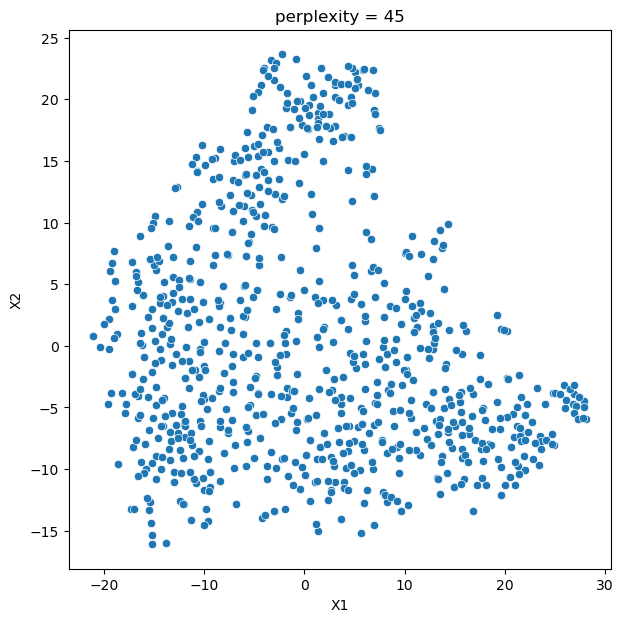

In [50]:
for i in range(10, 50, 5):
    tsne = TSNE(n_components = 2, random_state = 1, perplexity = i)
    
    data_tsne = tsne.fit_transform(data_scaled)
    
    data_tsne = pd.DataFrame(data_tsne)
    
    data_tsne.columns = ['X1', 'X2']
    
    plt.figure(figsize = (7, 7))
    
    sns.scatterplot(x = 'X1', y = 'X2', data = data_tsne)
    
    plt.title("perplexity = {}".format(i))

All the plots with different perplexity values imply that there is no undelying pattern in the data.
this shows that observing patterns in data projection and vizualization techniques like PCA and t-SNE is dependant on the nature of the data. 


Lets try Air pollution dataset

In [52]:
data_air_pol = pd.read_csv(r"C:\Users\amrel\Downloads\AirPollution.csv")
data_air_pol.head()

,SrNo,Date,NO,CO,NO2,O3,SO2,PM2.5,Benzene,Toulene,...,WindSpeed,VerticalWindSpeed,Solar,BarPressure,Weather,PD_PM2.5,PD_PM10,PD_NO2,PD_SO2,PD_CO
0,1,04-04-2015,7.22,1.77,47.94,51.07,16.88,48.99,2.53,9.65,...,1.22,0.08,162.18,732.25,Summer,NaN,NaN,NaN,NaN,NaN
1,2,05-04-2015,6.99,0.22,45.27,19.26,16.71,60.20,3.19,11.10,...,0.62,-0.04,99.37,734.05,Summer,48.99,82.85,47.94,16.88,1.77
2,3,09-04-2015,7.60,0.50,59.86,94.29,13.11,46.93,2.29,8.61,...,1.55,-0.17,146.94,728.08,Summer,NaN,NaN,NaN,NaN,NaN
3,4,10-04-2015,7.57,0.77,63.56,66.91,16.19,112.95,3.92,10.76,...,1.18,-0.15,150.07,730.47,Summer,46.93,171.36,59.86,13.11,0.50
4,5,11-04-2015,8.34,0.48,61.99,69.48,20.28,104.87,5.19,15.95,...,0.88,0.15,137.01,730.62,Summer,112.95,232.22,63.56,16.19,0.77


In [53]:
data_air_pol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SrNo               403 non-null    int64  
 1   Date               403 non-null    object 
 2   NO                 401 non-null    float64
 3   CO                 402 non-null    float64
 4   NO2                401 non-null    float64
 5   O3                 397 non-null    float64
 6   SO2                399 non-null    float64
 7   PM2.5              401 non-null    float64
 8   Benzene            402 non-null    float64
 9   Toulene            402 non-null    float64
 10  P_Xylene           372 non-null    float64
 11  NOx                401 non-null    float64
 12  PM10               401 non-null    float64
 13  WindDirection      402 non-null    float64
 14  NH3                401 non-null    float64
 15  RH                 402 non-null    float64
 16  Temp               401 non

In [54]:
data_air_pol.isnull().sum()

SrNo                  0
Date                  0
NO                    2
CO                    1
NO2                   2
O3                    6
SO2                   4
PM2.5                 2
Benzene               1
Toulene               1
P_Xylene             31
NOx                   2
PM10                  2
WindDirection         1
NH3                   2
RH                    1
Temp                  2
WindSpeed             1
VerticalWindSpeed     2
Solar                 2
BarPressure           2
Weather               0
PD_PM2.5             10
PD_PM10              11
PD_NO2               12
PD_SO2               13
PD_CO                11
dtype: int64

In [55]:
#dropping the unneccary columns
data_air_pol.drop(columns = ['SrNo', 'Date'], inplace = True)

In [56]:
for col in data_air_pol.columns:

    if col == 'Weather':
        data_air_pol[col].fillna(value = data_air_pol[col].mode()[0], inplace = True)

    else:
        data_air_pol[col].fillna(value = data_air_pol[col].median(), inplace = True)

C:\Users\amrel\AppData\Local\Temp\ipykernel_30600\351295768.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_air_pol[col].fillna(value = data_air_pol[col].median(), inplace = True)
C:\Users\amrel\AppData\Local\Temp\ipykernel_30600\351295768.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [57]:
data_air_pol = pd.get_dummies(data_air_pol, drop_first = True)

In [58]:
scaler1 = StandardScaler()
data_air_pol_scaled = scaler1.fit_transform(data_air_pol)

In [59]:
data_air_pol_scaled = pd.DataFrame(data_air_pol_scaled, columns = data_air_pol.columns)

PCA

In [60]:
n = data_air_pol_scaled.shape[1]

pca1 = PCA(n_components = n, random_state = 1)
data_air_pol_pca1 = pd.DataFrame(pca1.fit_transform(data_air_pol_scaled))

exp_var1 = pca1.explained_variance_ratio_

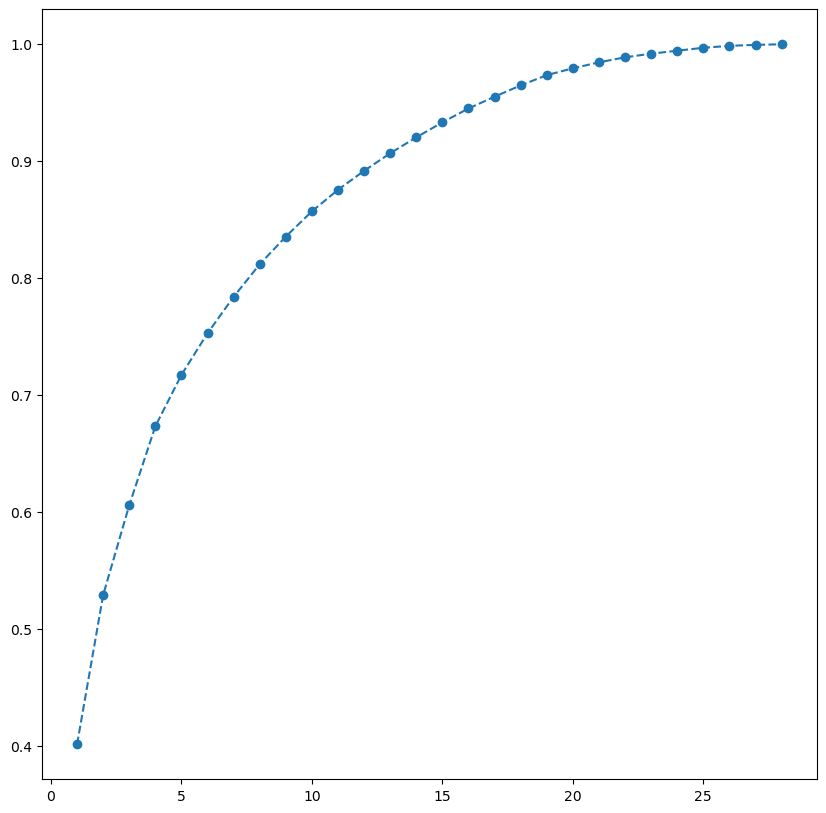

In [61]:
plt.figure(figsize=(10, 10))

plt.plot(range(1, 29), pca1.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.show()

In [62]:
sum = 0

for ix, i in enumerate(exp_var1):
    sum = sum + i

    if(sum> 0.70):
        print("Number of PCs that exmplain at least 70% variance:", ix + 1)
        break

Number of PCs that exmplain at least 70% variance: 5


In [63]:
cols = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']

pc1 = pd.DataFrame(np.round(pca1.components_[:5,:],2), index = cols, columns = data_air_pol_scaled.columns)

In [64]:
def color_high(val):
    if val < -0.25:
        return 'background-color: blue'
    elif val > 0.25:
        return 'background-color: green'
    
pc1.style.map(color_high)

,NO,CO,NO2,O3,SO2,PM2.5,Benzene,Toulene,P_Xylene,NOx,PM10,WindDirection,NH3,RH,Temp,WindSpeed,VerticalWindSpeed,Solar,BarPressure,PD_PM2.5,PD_PM10,PD_NO2,PD_SO2,PD_CO,Weather_Monsoon,Weather_Spring,Weather_Summer,Weather_Winter
PC1,0.250000,0.210000,0.190000,0.020000,0.120000,0.260000,0.270000,0.250000,0.250000,0.240000,0.230000,0.090000,0.240000,0.100000,-0.210000,-0.200000,-0.030000,-0.180000,0.130000,0.240000,0.220000,0.180000,0.130000,0.190000,-0.100000,0.020000,-0.130000,0.170000
PC2,-0.050000,0.040000,-0.220000,-0.380000,-0.190000,-0.060000,0.090000,0.100000,0.070000,0.010000,-0.170000,-0.060000,0.040000,0.460000,-0.170000,-0.040000,-0.220000,-0.220000,-0.010000,-0.050000,-0.150000,-0.230000,-0.170000,0.050000,0.360000,-0.040000,-0.330000,0.120000
PC3,-0.180000,-0.180000,-0.180000,0.020000,0.200000,0.100000,-0.150000,-0.270000,-0.220000,-0.260000,0.100000,-0.030000,0.120000,0.020000,-0.300000,0.270000,-0.280000,-0.140000,0.290000,0.180000,0.190000,-0.080000,0.160000,-0.060000,-0.150000,0.190000,-0.020000,0.330000
PC4,0.140000,-0.000000,0.060000,0.180000,0.280000,-0.180000,0.010000,0.080000,0.030000,0.150000,-0.160000,0.130000,-0.080000,0.010000,-0.060000,-0.070000,-0.200000,0.110000,0.270000,-0.240000,-0.240000,-0.020000,0.240000,-0.130000,0.080000,0.530000,-0.280000,-0.250000
PC5,0.130000,0.030000,-0.240000,-0.080000,0.110000,0.140000,0.010000,-0.010000,0.100000,0.120000,0.200000,0.560000,-0.110000,-0.180000,0.200000,0.070000,-0.310000,0.270000,0.060000,0.030000,0.040000,-0.280000,0.080000,-0.070000,0.240000,-0.290000,0.050000,0.090000


The first principal component, PC1, seems to be related to hydrocarbons like Benzene, Toluene, and Xylene that are generated due to fuel combustion.
The second principal component, PC2, seems to be related to humidity (RH), Ozone level, and rain, i.e., the rainy season. Whenever humidity goes down, the Ozone level goes up - more sunshine. Higher humidity is an indication of rain which has the potential to wash away atmospheric pollution.
The third principal component, PC3, seems to be capturing air pressure - low pressure accompanies windy and rainy conditions, dispersing the pollution away. High pressure stills the wind allowing pollution to build up in urban areas.
The fourth principal component, PC4, seems to be associated with high values of toxic gases like SO2 and is also related to the weather.
The fifth principal component, PC5, seems to be explaining the direction of the wind which impacts air pollution irrespective of the concentration of all pollutants. If the wind is blowing towards an urban area from an industrial area then pollution levels are likely to be higher in the town or city than if the air is blowing from another direction, for example, open farmland

T-SNE

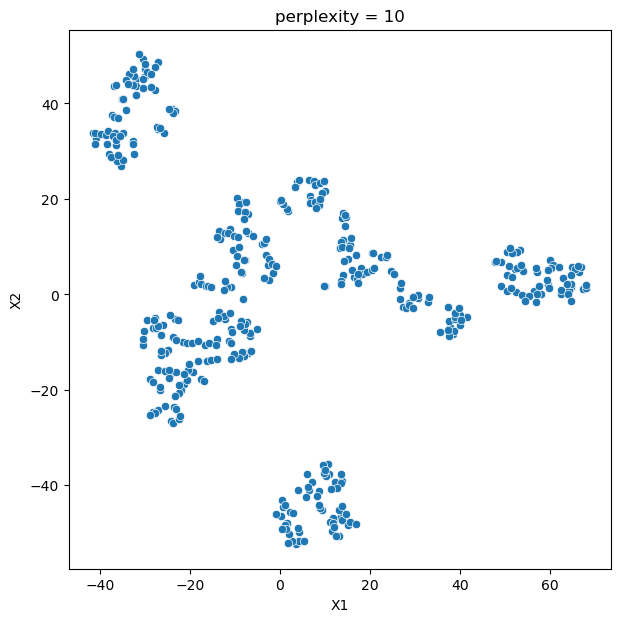

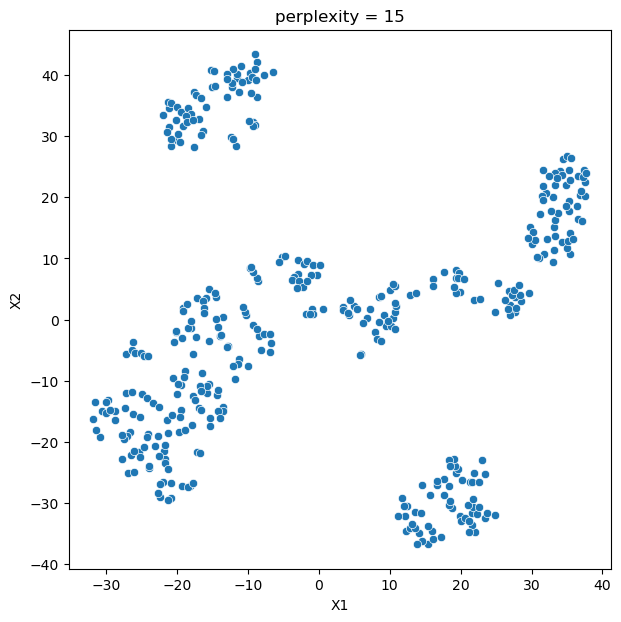

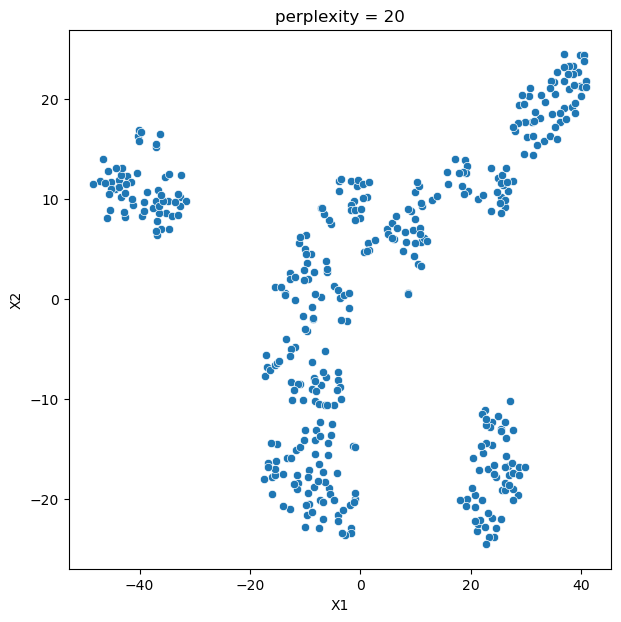

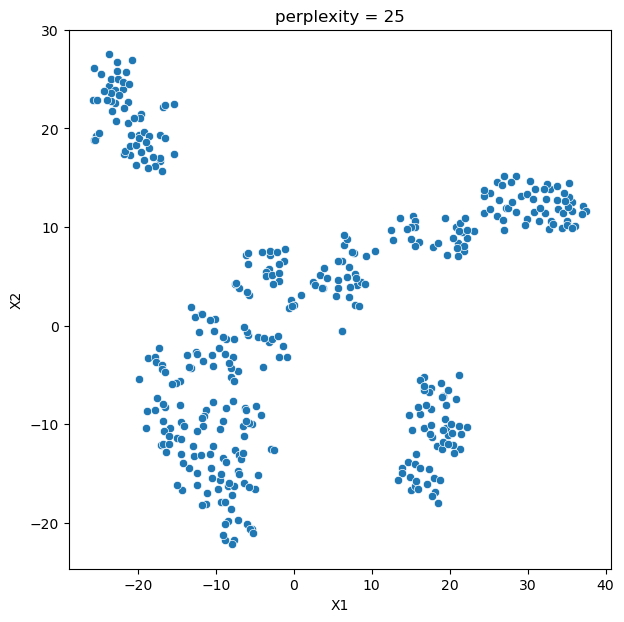

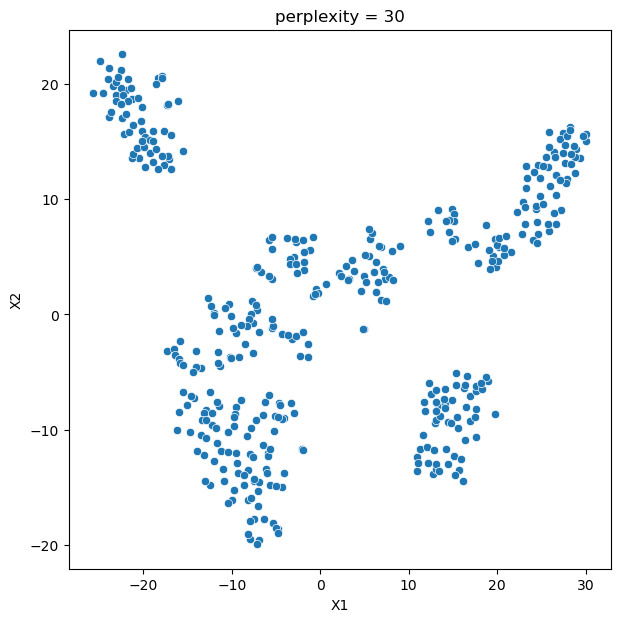

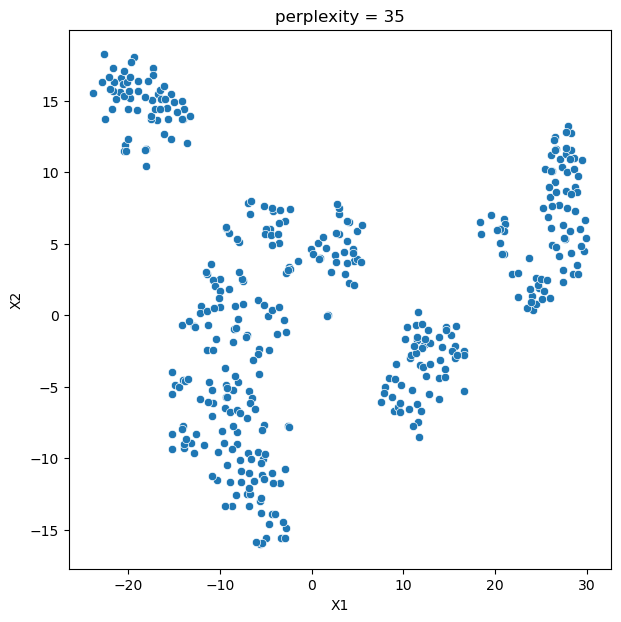

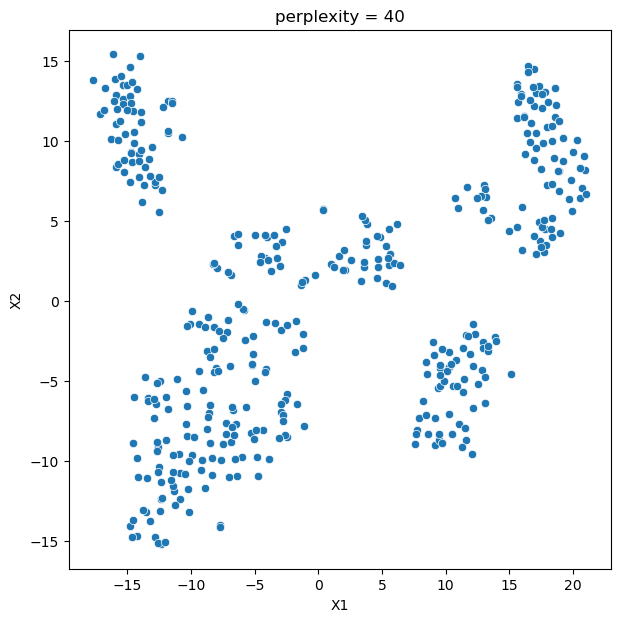

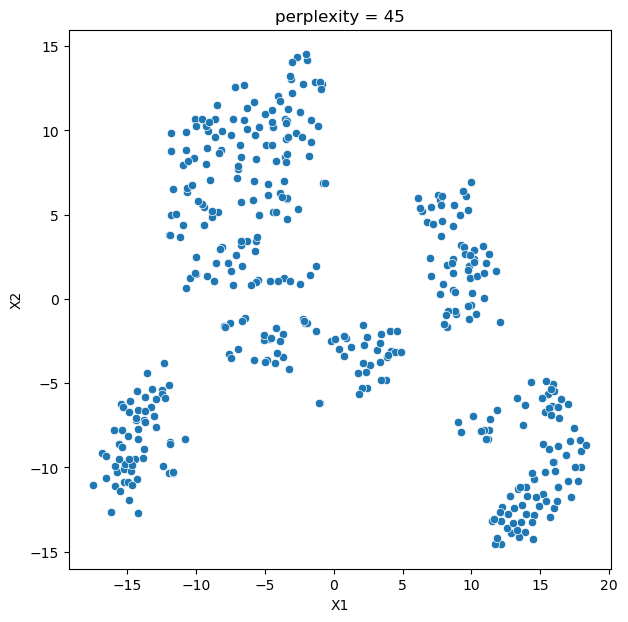

In [65]:
for i in range(10, 50, 5):
    tsne = TSNE(n_components = 2, random_state = 1, perplexity = i)
    
    data_air_pol_tsne = tsne.fit_transform(data_air_pol_scaled)
    
    data_air_pol_tsne = pd.DataFrame(data_air_pol_tsne)
    
    data_air_pol_tsne.columns = ['X1', 'X2']
    
    plt.figure(figsize = (7,7))
    
    sns.scatterplot(x = 'X1', y = 'X2', data = data_air_pol_tsne)
    
    plt.title("perplexity = {}".format(i))

We can clearly see 4 groups in the data
lets label these 4 groups using the values of the X1 and X2 axes

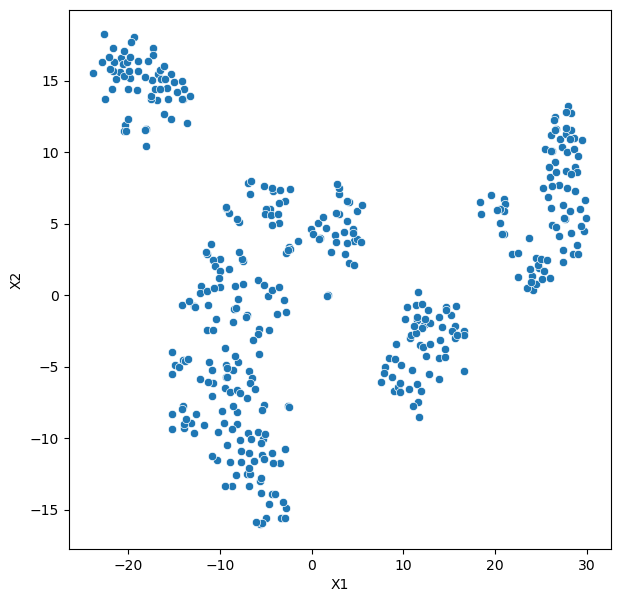

In [66]:
# Fitting t-SNE with number of components equal to 2
tsne = TSNE(n_components = 2, random_state = 1, perplexity = 35)

data_air_pol_tsne = tsne.fit_transform(data_air_pol_scaled)

# Converting the embeddings to a dataframe
data_air_pol_tsne = pd.DataFrame(data_air_pol_tsne, columns = ["X1", "X2"])

# Scatter plot for two components
plt.figure(figsize = (7, 7))

sns.scatterplot(x = 'X1', y = 'X2', data = data_air_pol_tsne)

plt.show()

In [67]:
# Let's assign points to 4 different groups
def grouping(x):
    first_component = x['X1']
    
    second_component = x['X2']
    
    if second_component > 12:
        return 'group_1'
    
    elif (second_component < -10) and (first_component > -10): 
        return 'group_2'
    
    elif (second_component < 12) and (first_component > -9):
        return 'group_3'
    
    else: 
        return 'group_4'

In [68]:
data_air_pol_tsne['groups'] = data_air_pol_tsne.apply(grouping, axis = 1)

<Axes: xlabel='X1', ylabel='X2'>

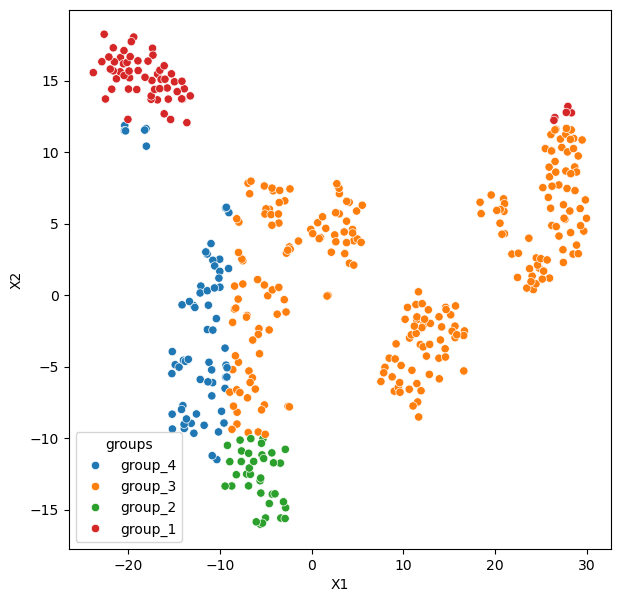

In [69]:
# Scatter plot for two components with hue
plt.figure(figsize = (7, 7))

sns.scatterplot(x = 'X1', y = 'X2', data = data_air_pol_tsne, hue = 'groups')

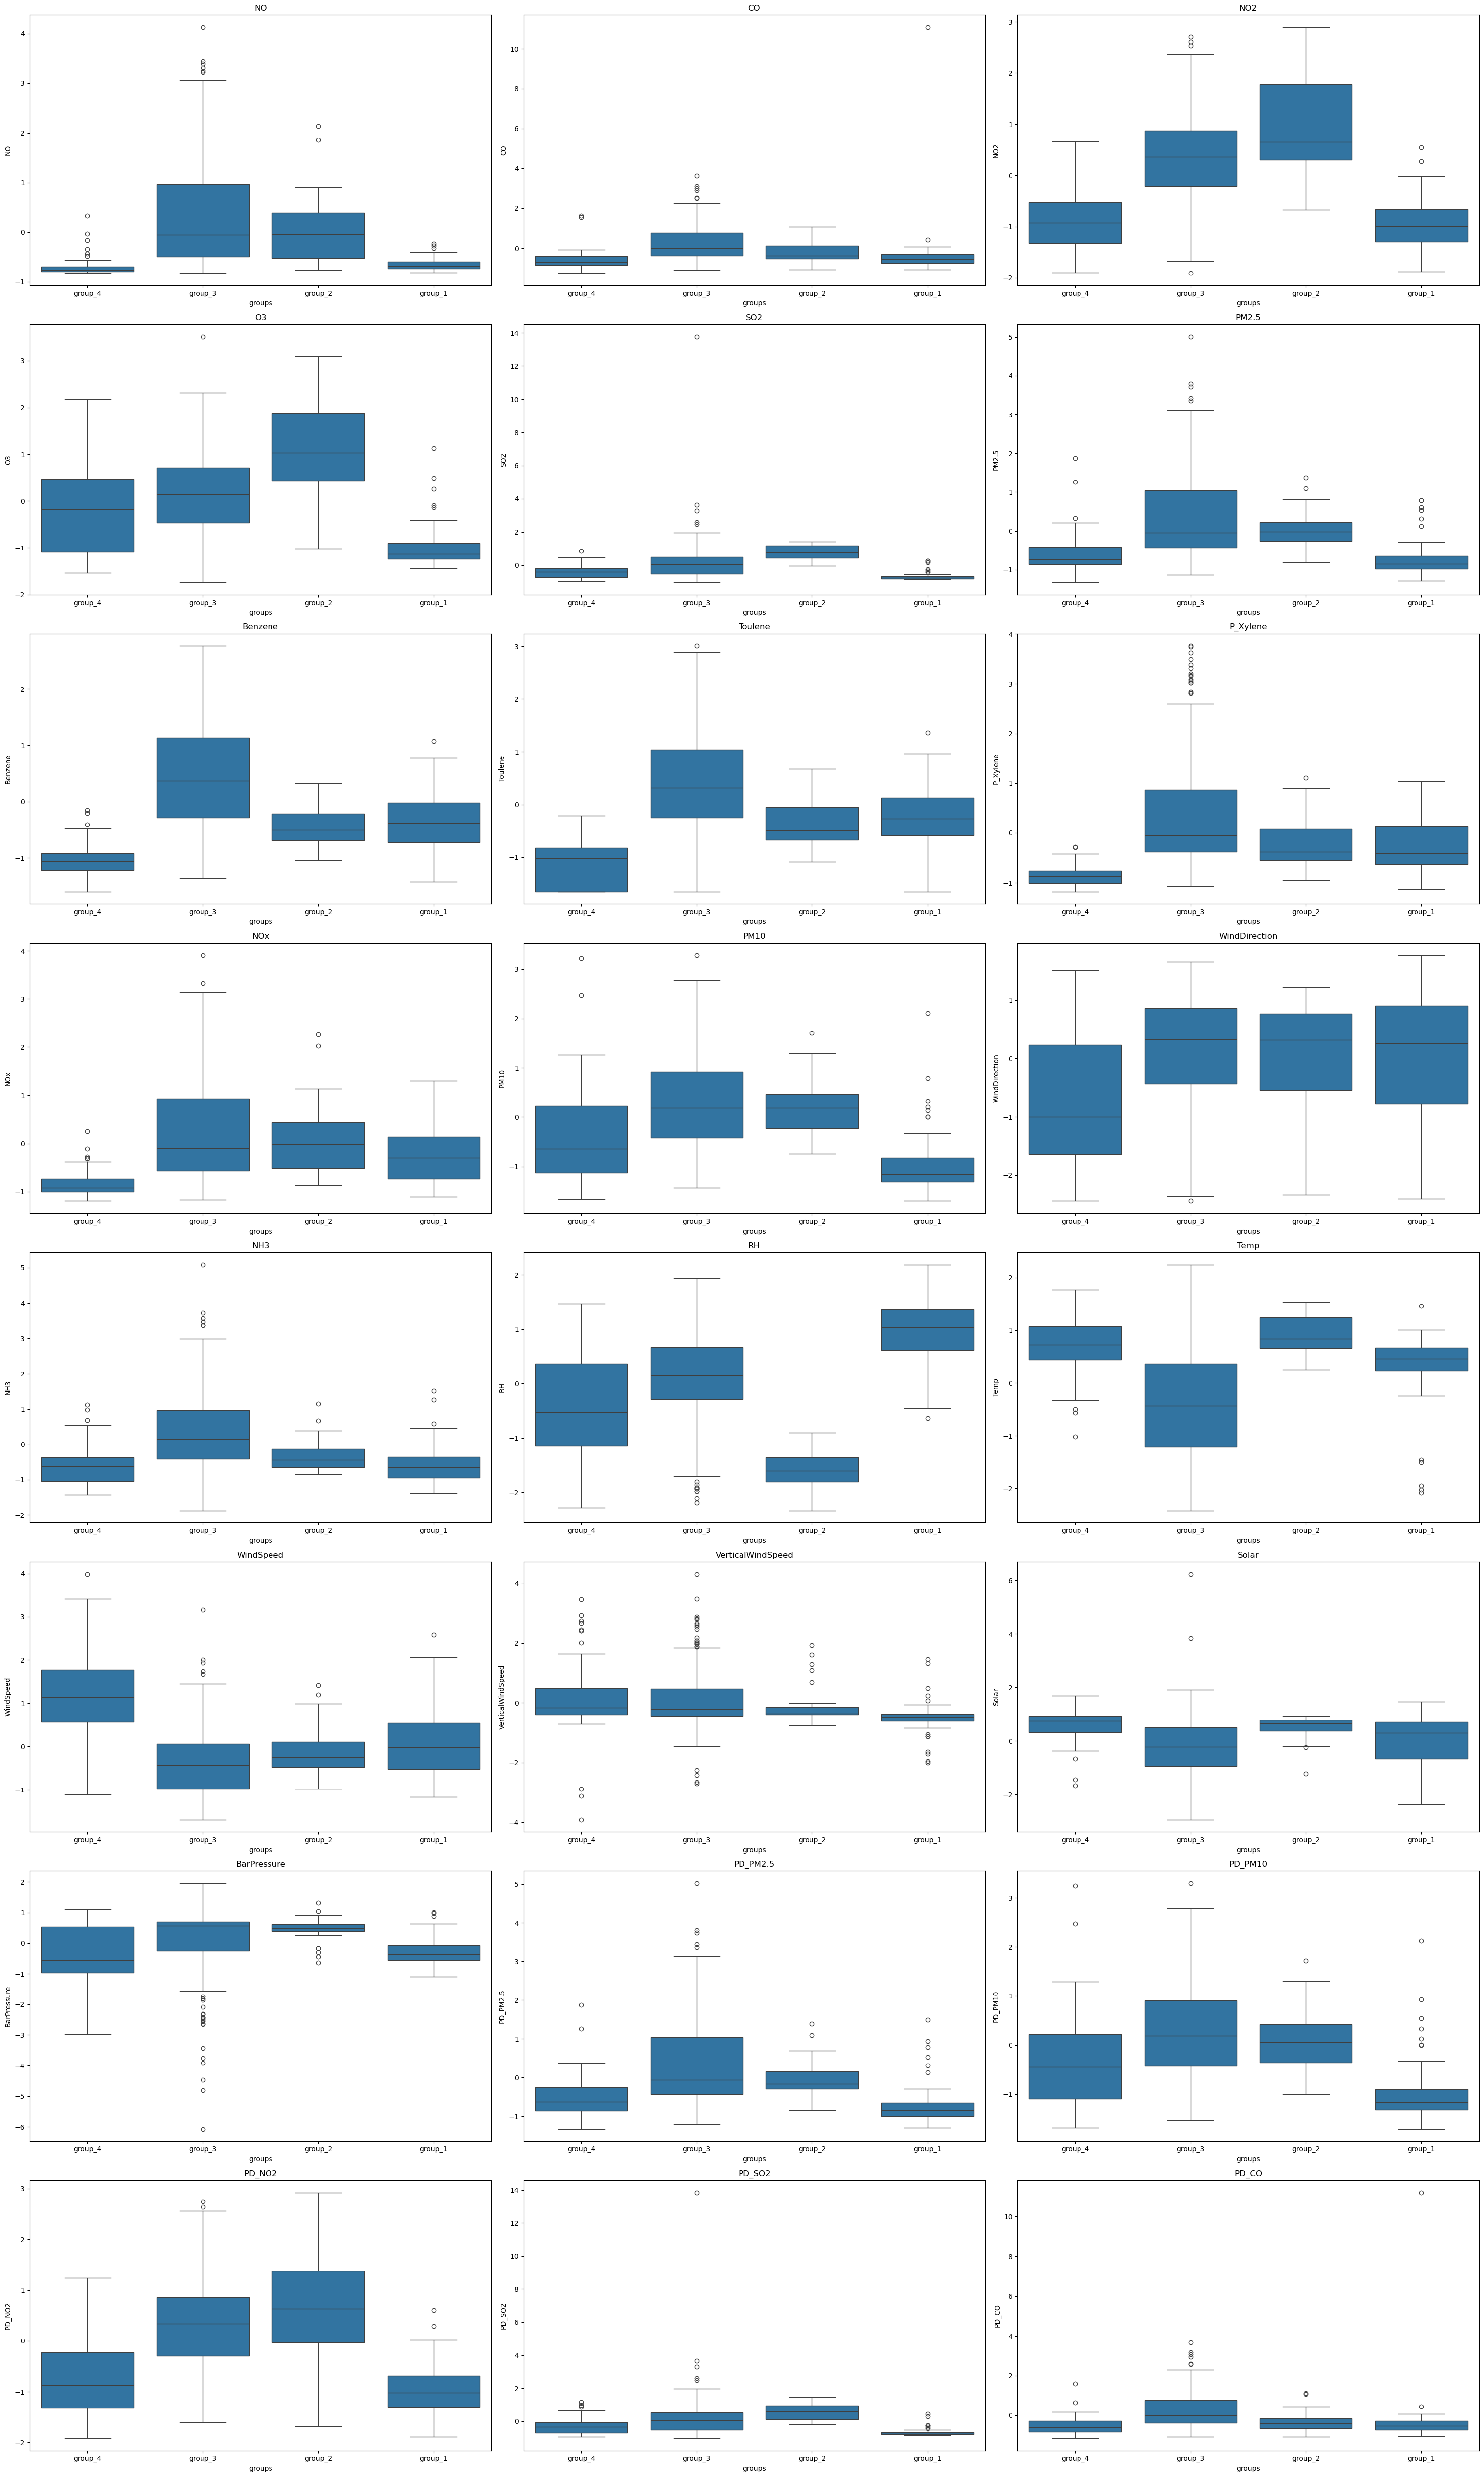

In [70]:
all_col = data_air_pol_scaled.columns[:-4].tolist()

plt.figure(figsize = (30, 50))

for i, variable in enumerate(all_col):
    plt.subplot(8, 3, i + 1)
    
    sns.boxplot(y=data_air_pol_scaled[variable], x=data_air_pol_tsne['groups'])
    
    plt.tight_layout()
    
    plt.title(variable)

plt.show()

Observations:

There are four groups in the data. Each group has a different set of characteristics.

Group 1 represents hot and humid areas. As there is less variability in the pressure, the wind speed is low. Higher humidity is an indication of rain which has the potential to wash away atmospheric pollution, resulting in low levels of pollutants - fine particulate matter and hydrocarbons.

Group 2 represents areas with medium humidity and temperature with low pressure and wind speed. The level of pollutants is medium. These might be developing urban areas where the Ozone (O3) concentration is medium to high, resulting in comparatively higher solar radiation.

Group 3 is the largest and represents low-humidity and high-temperature areas. As the variability in pressure is high, the wind speed is high. If the wind is blowing towards an urban area from an industrial area then pollution levels are likely to be higher in the town or city than if the air is blowing from another direction, for example, open farmland. These might be developed urban areas as they have the highest level of Ozone pollutant and solar radiation, which could be a result of pollutants emitted by cars, power plants, etc.

Group 4 represents industrial areas as it has a very high concentration of hydrocarbons, which are generally a result of fuel combustion. These areas have a high level of fine particulate matter and other pollutants. As there is less variability in air pressure, the wind speed is low.